# 04. 모델링 (EfficientNetB3 + Transfer Learning)

**목표**: 반려동물 피부 질환 탐지 정확도 **90% 이상** 달성

| 항목 | 내용 |
|------|------|
| 베이스 모델 | EfficientNetB3 (ImageNet 가중치) |
| 학습 방식 | Transfer Learning → Fine-tuning 2단계 |
| 분류 대상 | A1~A7 (7클래스 피부 병변) |
| 입력 크기 | 224×224 RGB |
| 데이터 | train 24,500 / val 5,250 / test 5,250 |

### 실험 계획
| 단계 | 내용 | 목표 |
|------|------|------|
| Phase 1 | 헤드만 학습 (Frozen backbone) | 베이스라인 확보 |
| Phase 2 | 상위 레이어 Fine-tuning | 90% 달성 |


## 0. GPU 확인

In [37]:
# ── GPU 확인 ──
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow 버전:', tf.__version__)
print('GPU 목록:', gpus)

if gpus:
    print(f'\n✅ GPU 사용 중: {gpus[0].name}')
    # GPU 메모리 동적 할당 (OOM 방지)
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('\n⚠️  GPU 없음 — 런타임 유형을 GPU로 변경하세요')
    print('   상단 메뉴 → 런타임 → 런타임 유형 변경 → T4 GPU')

TensorFlow 버전: 2.20.0
GPU 목록: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ GPU 사용 중: /physical_device:GPU:0


## 1. 라이브러리 로드

In [38]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 한글 폰트 설정
import matplotlib
import matplotlib.font_manager as fm

fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. 경로 설정 및 하이퍼파라미터

In [39]:
# ── 경로 설정 (Drive 기준) ──
DRIVE_ROOT = Path('/mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company')
PROCESSED  = DRIVE_ROOT / 'data'
MODEL_DIR  = DRIVE_ROOT / 'outputs/models'
LOG_DIR    = DRIVE_ROOT / 'outputs/logs'
FIG_DIR    = DRIVE_ROOT / 'outputs/figures'

for d in [MODEL_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# CSV 경로 확인
csv_path = PROCESSED / 'dataset_cleaned.csv'
print('CSV 존재 여부:', csv_path.exists())
if not csv_path.exists():
    print(f'\n⚠️  파일 없음: {csv_path}')
    print('Drive 업로드 경로를 확인하세요.')

# ── 하이퍼파라미터 ──
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

LESION_MAP = {
    'A1': 'A1 구진/플라크', 'A2': 'A2 비듬/각질', 'A3': 'A3 태선화/색소',
    'A4': 'A4 농포/여드름', 'A5': 'A5 미란/궤양', 'A6': 'A6 결절/종괴',
    'A7': 'A7 무증상(정상)'
}

print(f'입력 크기  : {IMG_SIZE}')
print(f'배치 크기  : {BATCH_SIZE}')
print(f'출력 경로  : {DRIVE_ROOT / "outputs"}')


CSV 존재 여부: True
입력 크기  : (224, 224)
배치 크기  : 32
출력 경로  : /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs


## 3. 데이터 로드 및 Generator 생성

In [40]:
df = pd.read_csv(PROCESSED / 'dataset_cleaned.csv')

# ── 이미지 경로 Colab용으로 변환 ──
# 로컬에서 작업한 경로(Windows 형식)를 Drive 경로로 치환
# raw_sub 이미지가 Drive에 올라가 있다고 가정
IMG_ROOT = DRIVE_ROOT / 'data/raw_sub'

target_col = 'sub_img_path' if 'sub_img_path' in df.columns else 'img_path'

# 파일명만 추출해서 Drive 경로로 재조합
df[target_col] = df[target_col].apply(
    lambda p: str(IMG_ROOT / str(p).replace('\\', '/').split('/')[-1])
)

df_train = df[df['split'] == 'train'].copy()
df_val   = df[df['split'] == 'val'].copy()
df_test  = df[df['split'] == 'test'].copy()

print(f'train : {len(df_train):,}장')
print(f'val   : {len(df_val):,}장')
print(f'test  : {len(df_test):,}장')

# 경로 샘플 확인
sample_path = df_train[target_col].iloc[0]
print(f'\n경로 샘플  : {sample_path}')
print(f'파일 존재  : {Path(sample_path).exists()}')

train : 24,492장
val   : 5,249장
test  : 5,246장

경로 샘플  : /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/data/raw_sub/IMG_D_A4_193221.jpg
파일 존재  : True


In [41]:
# ── 정규화 함수 ──
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    vertical_flip=True,              # 추가
    rotation_range=45,               # 30 → 45
    brightness_range=[0.7, 1.3],     # [0.8, 1.2] → [0.7, 1.3]
    zoom_range=0.2,                  # 0.1 → 0.2
    width_shift_range=0.2,           # 0.1 → 0.2
    height_shift_range=0.2,          # 0.1 → 0.2
    shear_range=0.2,                 # 추가
    channel_shift_range=20.0,        # 추가
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ── Generator 생성 ──
train_gen = train_datagen.flow_from_dataframe(
    dataframe=df_train, x_col=target_col, y_col='lesion',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=df_val, x_col=target_col, y_col='lesion',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=df_test, x_col=target_col, y_col='lesion',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# 정규화 검증
_batch = next(iter(train_gen))
print(f'배치 픽셀 범위: min={_batch[0].min():.3f}, max={_batch[0].max():.3f}, mean={_batch[0].mean():.3f}')
print('→ EfficientNetB3는 0~255 그대로 입력, 전처리는 모델 내부에서 처리')

CLASS_INDICES = train_gen.class_indices
NUM_CLASSES   = len(CLASS_INDICES)
print(f'\n클래스 인덱스: {CLASS_INDICES}')

Found 24492 validated image filenames belonging to 7 classes.
Found 5249 validated image filenames belonging to 7 classes.
Found 5246 validated image filenames belonging to 7 classes.
배치 픽셀 범위: min=0.000, max=255.000, mean=130.570
→ EfficientNetB3는 0~255 그대로 입력, 전처리는 모델 내부에서 처리

클래스 인덱스: {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}


In [42]:
# ── class_weight 계산 ──
lesion_classes    = np.array(sorted(df_train['lesion'].unique()))
lesion_weights    = compute_class_weight(
    class_weight='balanced', classes=lesion_classes, y=df_train['lesion']
)
lesion_weight_dict = {
    CLASS_INDICES[cls]: w for cls, w in zip(lesion_classes, lesion_weights)
}
print('lesion class_weight:', lesion_weight_dict)

lesion class_weight: {0: np.float64(0.999959172008329), 1: np.float64(0.999959172008329), 2: np.float64(1.000245037980887), 3: np.float64(1.0005310674455656), 4: np.float64(0.9996734693877551), 5: np.float64(0.999959172008329), 6: np.float64(0.9996734693877551)}


## 4. 모델 구성 (EfficientNetB3)



In [43]:
def build_model(num_classes: int, dropout_rate: float = 0.4):
    backbone = EfficientNetB3(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    inputs  = keras.Input(shape=(*IMG_SIZE, 3))
    x       = backbone(inputs, training=True)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(512, activation='relu')(x)
    x       = layers.Dropout(0.5)(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='EfficientNetB3_SkinDisease'), backbone


model, backbone = build_model(NUM_CLASSES)
model.summary(show_trainable=True)

Model: "EfficientNetB3_SkinDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_5 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb3 (Functional) │ (None, 7, 7, 1536)    │ 10,783,535 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_2  │ (None, 1536)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_2       │ (None, 1536)          │      6,144 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_6 (Dense)             │ (None, 512)           │    786,944 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_4 (Dropout)         │ (None, 512)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 256)           │    131,328 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_5 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_8 (Dense)             │ (None, 7)             │      1,799 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 11,709,750 (44.67 MB)

 Trainable params: 923,143 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

## 5. Phase 1 — Head만 학습 (Frozen Backbone)

In [44]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

timestamp = datetime.now().strftime('%Y%m%d_%H%M')

callbacks_phase1 = [
    ModelCheckpoint(
        MODEL_DIR / f'efficientnetb3_phase1_{timestamp}.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    CSVLogger(LOG_DIR / f'phase1_{timestamp}.csv')
]

print('Phase 1 학습 시작 — Backbone Frozen | Head 학습 중')

Phase 1 학습 시작 — Backbone Frozen | Head 학습 중


In [45]:
# ── 속도 측정 포함 Phase 1 학습 ──
t0 = time.time()

history_p1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    class_weight=lesion_weight_dict,
    verbose=1
)

p1_elapsed = time.time() - t0
p1_epochs  = len(history_p1.history['val_accuracy'])

print(f'\n[Phase 1 완료]')
print(f'  최고 val_accuracy : {max(history_p1.history["val_accuracy"]):.4f}')
print(f'  총 소요 시간      : {p1_elapsed/60:.1f}분  ({p1_epochs} epochs)')
print(f'  epoch당 평균      : {p1_elapsed/p1_epochs:.1f}초')

Epoch 1/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.2161 - loss: 2.1211 - top3_acc: 0.5323
Epoch 1: val_accuracy improved from None to 0.30215, saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_phase1_20260614_1146.keras

Epoch 1: finished saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_phase1_20260614_1146.keras
766/766 ━━━━━━━━━━━━━━━━━━━━ 352s 436ms/step - accuracy: 0.2359 - loss: 1.9490 - top3_acc: 0.5576 - val_accuracy: 0.3022 - val_loss: 1.7777 - val_top3_acc: 0.6376 - learning_rate: 0.0010
Epoch 2/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.2758 - loss: 1.8145 - top3_acc: 0.6031
Epoch 2: val_accuracy improved from 0.30215 to 0.31663, saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_phase1_20260614_1146.keras

Epoch 2: finished saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_pha

## 6. 학습 곡선 시각화 (Phase 1)

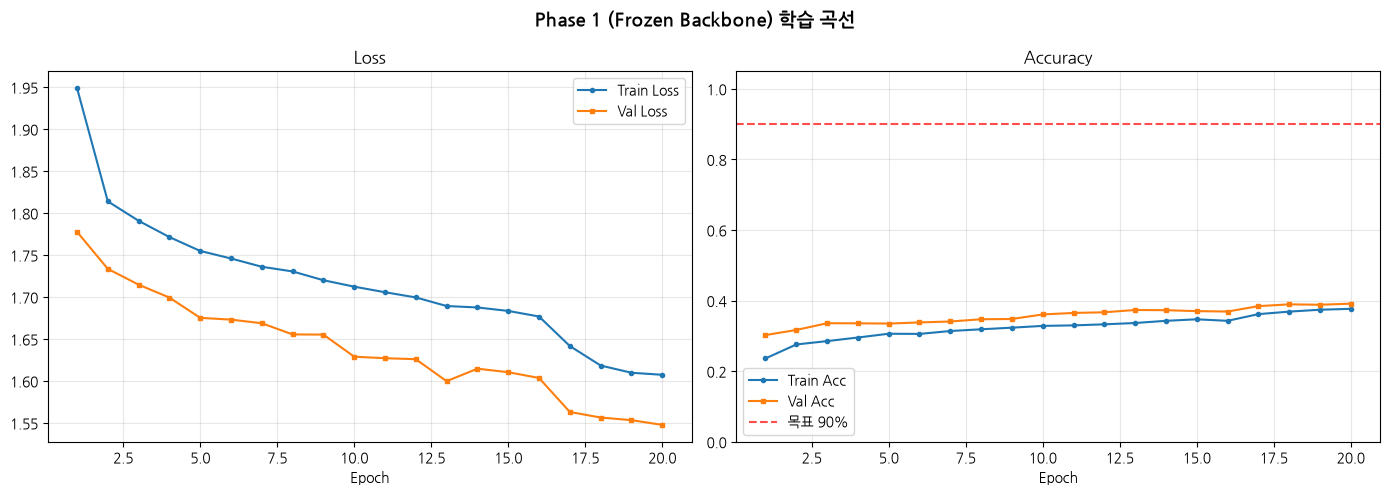

In [46]:
def plot_history(history, phase_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{phase_name} 학습 곡선', fontsize=14, fontweight='bold')
    epochs = range(1, len(history.history['loss']) + 1)

    axes[0].plot(epochs, history.history['loss'],     label='Train Loss', marker='o', markersize=3)
    axes[0].plot(epochs, history.history['val_loss'], label='Val Loss',   marker='s', markersize=3)
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history.history['accuracy'],     label='Train Acc', marker='o', markersize=3)
    axes[1].plot(epochs, history.history['val_accuracy'], label='Val Acc',   marker='s', markersize=3)
    axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='목표 90%')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history_p1, 'Phase 1 (Frozen Backbone)',
             save_path=FIG_DIR / f'phase1_curves_{timestamp}.png')

## 7. Phase 2 — Fine-tuning (상위 레이어 해동)

In [47]:
backbone.trainable = True

print(f'해동 레이어 수: {sum(1 for l in backbone.layers if l.trainable)}')
print(f'동결 레이어 수: {sum(1 for l in backbone.layers if not l.trainable)}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_phase2 = [
    ModelCheckpoint(
        MODEL_DIR / f'efficientnetb3_phase2_{timestamp}.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
    ),
    CSVLogger(LOG_DIR / f'phase2_{timestamp}.csv')
]

print('\nPhase 2 학습 시작 — 전체 레이어 해동 | lr=1e-5')

해동 레이어 수: 385
동결 레이어 수: 0

Phase 2 학습 시작 — 전체 레이어 해동 | lr=1e-5


In [48]:
t0 = time.time()

history_p2 = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    class_weight=lesion_weight_dict,
    verbose=1
)

p2_elapsed = time.time() - t0
p2_epochs  = len(history_p2.history['val_accuracy'])
best_val   = max(history_p2.history['val_accuracy'])

print(f'\n[Phase 2 완료]')
print(f'  최고 val_accuracy : {best_val:.4f}')
print(f'  총 소요 시간      : {p2_elapsed/60:.1f}분  ({p2_epochs} epochs)')
print(f'  목표 달성 여부    : {"✅ 90% 달성!" if best_val >= 0.9 else "❌ 미달"}')

Epoch 1/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.2823 - loss: 1.8509 - top3_acc: 0.6125
Epoch 1: val_accuracy improved from None to 0.36197, saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_phase2_20260614_1146.keras

Epoch 1: finished saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_phase2_20260614_1146.keras
766/766 ━━━━━━━━━━━━━━━━━━━━ 441s 502ms/step - accuracy: 0.3043 - loss: 1.8134 - top3_acc: 0.6402 - val_accuracy: 0.3620 - val_loss: 1.6973 - val_top3_acc: 0.7041 - learning_rate: 5.0000e-05
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.3522 - loss: 1.7419 - top3_acc: 0.6836
Epoch 2: val_accuracy improved from 0.36197 to 0.39303, saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_phase2_20260614_1146.keras

Epoch 2: finished saving model to /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3

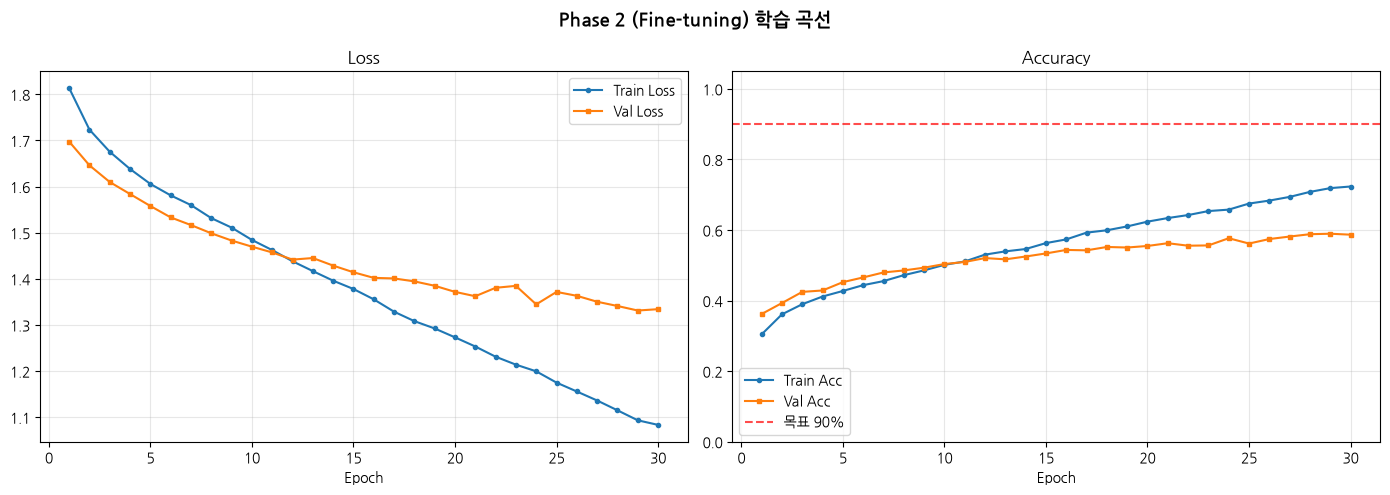

In [49]:
plot_history(history_p2, 'Phase 2 (Fine-tuning)',
             save_path=FIG_DIR / f'phase2_curves_{timestamp}.png')

## 8. 테스트셋 최종 평가

In [50]:
print('테스트셋 평가 중...')
test_loss, test_acc, test_top3 = model.evaluate(test_gen, verbose=1)

print(f'\n{"="*40}')
print(f'  테스트 Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Top-3 Accuracy  : {test_top3:.4f}  ({test_top3*100:.2f}%)')
print(f'  Test Loss       : {test_loss:.4f}')
print(f'  목표 달성 여부  : {"✅ 90% 달성!" if test_acc >= 0.9 else "❌ 미달 → 섹션 9 참고"}')
print(f'{"="*40}')

테스트셋 평가 중...
164/164 ━━━━━━━━━━━━━━━━━━━━ 52s 319ms/step - accuracy: 0.5759 - loss: 1.3612 - top3_acc: 0.8538

  테스트 Accuracy : 0.5759  (57.59%)
  Top-3 Accuracy  : 0.8538  (85.38%)
  Test Loss       : 1.3612
  목표 달성 여부  : ❌ 미달 → 섹션 9 참고


In [51]:
# ── 클래스별 분류 리포트 ──
test_gen.reset()
y_pred_prob  = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_prob, axis=1)
y_true       = test_gen.classes
idx_to_label = {v: k for k, v in CLASS_INDICES.items()}
target_names = [LESION_MAP[idx_to_label[i]] for i in range(NUM_CLASSES)]

print('\n[클래스별 분류 리포트]')
print(classification_report(y_true, y_pred, target_names=target_names))

164/164 ━━━━━━━━━━━━━━━━━━━━ 54s 303ms/step

[클래스별 분류 리포트]
              precision    recall  f1-score   support

   A1 구진/플라크       0.54      0.48      0.51       749
    A2 비듬/각질       0.41      0.48      0.44       750
   A3 태선화/색소       0.50      0.53      0.51       750
   A4 농포/여드름       0.65      0.55      0.60       749
    A5 미란/궤양       0.68      0.81      0.74       750
    A6 결절/종괴       0.66      0.80      0.72       750
  A7 무증상(정상)       0.61      0.40      0.48       748

    accuracy                           0.58      5246
   macro avg       0.58      0.58      0.57      5246
weighted avg       0.58      0.58      0.57      5246



### 클래스별 성능 분석 (1차 실험)

| 클래스 | F1-score | 비고 |
|--------|----------|------|
| A5 미란/궤양 | 0.74 | 가장 높음 — 시각적 특징 뚜렷 |
| A6 결절/종괴 | 0.72 | 양호 |
| A4 농포/여드름 | 0.60 | 양호 |
| A1 구진/플라크 | 0.51 | 개선 필요 |
| A3 태선화/색소 | 0.51 | 개선 필요 |
| A7 무증상(정상) | 0.46 | 가장 낮음 — 정상과 병변 구분 어려움 |
| A2 비듬/각질 | 0.46 | 가장 낮음 — 다른 클래스와 혼동 많음 |

## 9. 혼동 행렬 시각화

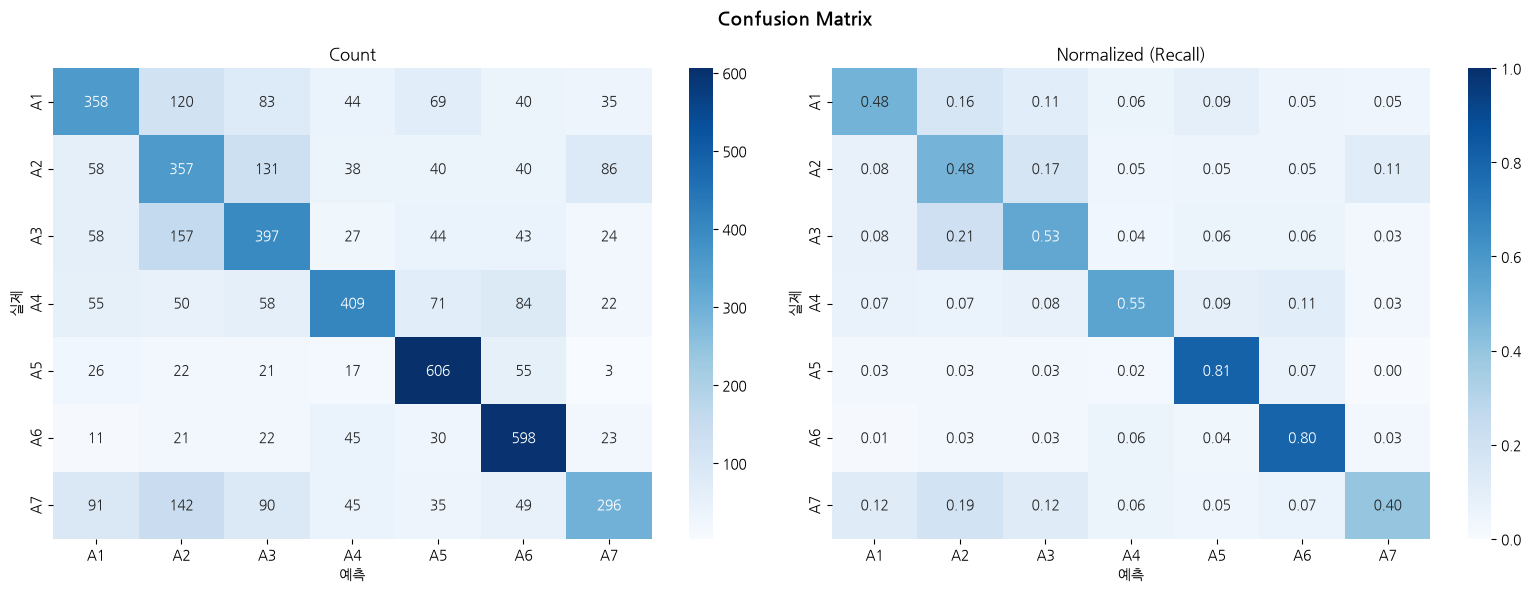

In [52]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
short_names = [idx_to_label[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')

sns.heatmap(cm,      annot=True, fmt='d',   cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title('Count'); axes[0].set_xlabel('예측'); axes[0].set_ylabel('실제')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalized (Recall)'); axes[1].set_xlabel('예측'); axes[1].set_ylabel('실제')

plt.tight_layout()
plt.savefig(FIG_DIR / f'confusion_matrix_{timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 모델 저장

In [53]:
final_path = MODEL_DIR / f'efficientnetb3_final_{timestamp}.keras'
model.save(final_path)
print(f'모델 저장 완료: {final_path}')

summary = {
    'timestamp'             : timestamp,
    'env'                   : 'WSL GPU',
    'base_model'            : 'EfficientNetB3',
    'normalization'         : 'EDA custom (domain-specific)',
    'phase1_best_val_acc'   : max(history_p1.history['val_accuracy']),
    'phase1_time_min'       : round(p1_elapsed / 60, 1),
    'phase2_best_val_acc'   : max(history_p2.history['val_accuracy']),
    'phase2_time_min'       : round(p2_elapsed / 60, 1),
    'test_acc'              : test_acc,
    'test_top3_acc'         : test_top3,
    'test_loss'             : test_loss,
    'target_achieved'       : test_acc >= 0.9
}
pd.DataFrame([summary]).to_csv(LOG_DIR / f'result_summary_{timestamp}.csv', index=False)

print()
print('=' * 50)
print(' 최종 결과 요약')
print('=' * 50)
for k, v in summary.items():
    print(f'  {k:<28}: {v}')
print('=' * 50)

모델 저장 완료: /mnt/c/Users/syaaa/OneDrive/바탕 화면/SAG-company/outputs/models/efficientnetb3_final_20260614_1146.keras

 최종 결과 요약
  timestamp                   : 20260614_1146
  env                         : WSL GPU
  base_model                  : EfficientNetB3
  normalization               : EDA custom (domain-specific)
  phase1_best_val_acc         : 0.39112213253974915
  phase1_time_min             : 106.6
  phase2_best_val_acc         : 0.5894455909729004
  phase2_time_min             : 163.8
  test_acc                    : 0.5758673548698425
  test_top3_acc               : 0.8537933826446533
  test_loss                   : 1.3611969947814941
  target_achieved             : False


---

## 노트북 완료 ✅

| Phase | 내용 | 결과 변수 |
|-------|------|----------|
| Phase 1 | Frozen Backbone + Head 학습 | `history_p1` |
| Phase 2 | 상위 80레이어 Fine-tuning | `history_p2` |
| 평가 | 테스트셋 최종 정확도 | `test_acc` |

**1차 실험 결과**: test_acc 57.3%, Top-3 85.2% — 과적합 확인 → 11번 셀 전략 적용 후 재실행

## 11. 과적합 개선 전략 (2차 실험)

Phase 2 학습 곡선에서 15 epoch 이후 val_acc 정체 + val_loss 상승 확인 → 과적합으로 판단

| 전략 | 변경 내용 | 기대 효과 |
|------|-----------|-----------|
| Dropout 강화 | 0.4 → 0.5 / 0.3 → 0.4 | 과적합 억제 |
| 해동 레이어 축소 | UNFREEZE_FROM -80 → -50 | 과적합 억제 |
| Label Smoothing | categorical_crossentropy → label_smoothing=0.1 | 일반화 향상 |
| EarlyStopping | patience 7 → 5 | 과적합 시점 조기 종료 |

위 항목 수정 후 Phase 1부터 재실행

## 12. 2차 실험 결과 및 3차 전략

### 2차 실험 결과 (Dropout 강화 + Label Smoothing + 해동 레이어 축소)

| 항목 | 결과 |
|------|------|
| test_acc | 59% |
| Top-3 Accuracy | - |
| 과적합 여부 | Train 80% vs Val 59% → 여전히 심함 |
| Val Loss | 10 epoch부터 평탄 |

**클래스별 주요 문제**
- A7 무증상(정상): recall 0.39 → 정상을 병변으로 오분류 多
- A2 비듬/각질: f1 0.48 → 다른 클래스와 혼동 多
- A5 미란/궤양, A6 결절/종괴: f1 0.74, 0.73 → 상대적으로 양호

### 3차 전략 — 전체 레이어 해동 + lr 낮추기

| 변경 항목 | 기존 | 변경 |
|-----------|------|------|
| 해동 레이어 | 상위 50개 | 전체 해동 |
| Learning Rate | 1e-4 | 1e-5 |

과적합이 또 발생하면 → 데이터 증강 강화로 우회

## 13. 3차 실험 결과 및 4차 전략

### 3차 실험 결과 (전체 레이어 해동 + lr=1e-5)

| 항목 | 결과 |
|------|------|
| test_acc | 50% |
| 과적합 여부 | Train vs Val 격차 없음 → 해결 |
| 문제점 | lr=1e-5가 너무 낮아 학습 속도 느림, 30 epoch에서 미수렴 |

**클래스별 주요 문제**
- A1 구진/플라크: f1 0.40 → 개선 필요
- A7 무증상(정상): f1 0.42 → 여전히 낮음

### 4차 전략 — 이어 학습 (30 epoch 추가)

- 그래프가 30 epoch에서도 계속 하강 중 → 수렴 전에 멈춘 것으로 판단
- 저장된 모델 불러와서 추가 학습

In [ ]:
# ── Phase 2 이어서 학습 (30 epoch 추가) ──
# model = keras.models.load_model(
#     MODEL_DIR / f'efficientnetb3_phase2_{timestamp}.keras'
# )

# t0 = time.time()

# history_p2_cont = model.fit(
#     train_gen,
#     epochs=30,
#     validation_data=val_gen,
#     callbacks=callbacks_phase2,
#     class_weight=lesion_weight_dict,
#     verbose=1
# )

# p2_cont_elapsed = time.time() - t0
# best_cont = max(history_p2_cont.history['val_accuracy'])

# print(f'\n[Phase 2 이어 학습 완료]')
# print(f'  최고 val_accuracy : {best_cont:.4f}')
# print(f'  총 소요 시간      : {p2_cont_elapsed/60:.1f}분')
# print(f'  목표 달성 여부    : {"✅ 90% 달성!" if best_cont >= 0.9 else "❌ 미달"}')

In [ ]:
# plot_history(history_p2_cont, 'Phase 2 이어 학습',
#              save_path=FIG_DIR / f'phase2_cont_curves_{timestamp}.png')

## 14. 4차 실험 결과 및 5차 전략

### 4차 실험 결과 (전체 레이어 해동 + 이어 학습 30 epoch 추가)

| 항목 | 결과 |
|------|------|
| Val Acc | 56% |
| 과적합 여부 | Train 69% vs Val 56% → 격차 재발 |
| Val Loss | 15 epoch부터 평탄 |

실험별 과적합 추이

| 실험 | Train Acc | Val Acc | 격차 |
|------|-----------|---------|------|
| 2차 | 80% | 59% | 21% |
| 3차 | 55% | 50% | 5% |
| 4차 | 69% | 56% | 13% |

### 5차 전략 — 데이터 증강 강화 + lr 조정

| 변경 항목 | 기존 | 변경 |
|-----------|------|------|
| vertical_flip | 없음 | 추가 |
| rotation_range | 30 | 45 |
| brightness_range | [0.8, 1.2] | [0.7, 1.3] |
| zoom_range | 0.1 | 0.2 |
| width/height_shift_range | 0.1 | 0.2 |
| shear_range | 없음 | 0.2 추가 |
| channel_shift_range | 없음 | 20.0 추가 |
| Learning Rate | 1e-5 | 5e-5 |

## 15. 5차 실험 결과 및 전체 실험 요약

### 5차 실험 결과 (데이터 증강 강화 + lr=5e-5)

| 항목 | 결과 |
|------|------|
| Val Acc | 약 59~60% |
| 과적합 여부 | 15 epoch부터 재발 — 증강 강화에도 동일 패턴 반복 |

---

## 전체 실험 요약

| 실험 | 주요 변경 | Val Acc | 과적합 |
|------|-----------|---------|--------|
| 1차 | 기본 설정 (UNFREEZE -80, lr=1e-4) | 58.5% | 심함 (Train 80% vs Val 58%) |
| 2차 | Dropout 강화 + Label Smoothing + UNFREEZE -50 | 59% | 여전히 심함 |
| 3차 | 전체 레이어 해동 + lr=1e-5 | 50% | 해결됐지만 성능 하락 |
| 4차 | 3차 이어 학습 30 epoch 추가 | 56% | 격차 재발 |
| 5차 | 데이터 증강 강화 + lr=5e-5 | 59~60% | 15 epoch부터 재발 |

**공통 패턴**: 10~15 epoch 이후 Val Loss 평탄 → 모델이 학습 데이터에 수렴하는 한계 반복

---

## 정체 해결 방향

### 방향 1 — 데이터 확장
| 방법 | 기대 효과 | 난이도 |
|------|-----------|--------|
| 샘플 수 증가 (24,500 → 100,000장) | 과적합 억제, +5~10% | 중 |
| 전체 데이터 50만장 학습 | 효과 크지만 학습 시간 50시간 이상 | 상 |

### 방향 2 — 모델 교체
| 방법 | 기대 효과 | 난이도 |
|------|-----------|--------|
| EfficientNetB5/B7 | 표현력 향상, +3~5% | 중 |
| ViT (Vision Transformer) | 전역 특징 학습, 피부 질환에 강점 | 상 |

### 방향 3 — 학습 전략 개선
| 방법 | 기대 효과 | 난이도 |
|------|-----------|--------|
| Cosine Annealing LR | 수렴 안정화 | 하 |
| Mixup 증강 | 클래스 경계 학습 강화 | 중 |
| Class-Aware Sampling | A7(정상) 분류 개선 | 중 |
| TTA (Test Time Augmentation) | 추론 시 +1~2% | 하 |

### 우선 추천 순서
1. 샘플 수 10만장으로 증가 → 가장 현실적이고 효과적
2. Cosine Annealing LR 적용 → 코드 수정 최소화
3. EfficientNetB5로 교체 → 성능 향상 기대